# EFM Synthetic

Evaluates differentiable fuzzy rule ensembles across controlled synthetic datasets.
Ground-truth features, interactions and rules are known — enabling objective measurement
of both predictive performance and interpretability.

**Models:** SMTE (Student-t), GMTE (Gaussian), HYP (Piecewise-linear), SC (State-coupled),
EBM, XGBoost, CatBoost, RuleFit

In [1]:
%%capture
!git clone https://github.com/EmotionEngineer/efm.git
%cd efm
!pip install -e ".[dev]"

In [2]:
%%capture
!pip install numpy pandas scikit-learn matplotlib seaborn torch xgboost catboost interpret imodels

In [3]:
import os, re, json, time, math, random, warnings, platform
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.multiclass import OneVsRestClassifier

from efm import EFM
from efm.trainer import EFMTrainer, TrainConfig

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

try:
    from catboost import CatBoostRegressor, CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

try:
    from interpret.glassbox import ExplainableBoostingRegressor, ExplainableBoostingClassifier
    HAS_EBM = True
except ImportError:
    HAS_EBM = False

try:
    from imodels import RuleFitRegressor, RuleFitClassifier
    HAS_RULEFIT = True
except ImportError:
    HAS_RULEFIT = False

warnings.filterwarnings("ignore")

# Experiment constants
SEED = 42
SEEDS = [SEED]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_MAIN = 2000
D_MAIN = 15
N_RULES = 32
EPOCHS = 150
PATIENCE = 20
BATCH_SIZE = 256
LR = 3e-3
WEIGHT_DECAY = 1e-4
L1_MASK = 1e-4
RULE_BETA = 6.0

TRAIN_TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.20

GRADIENT_N_SAMPLES = 300
TOP_RULES_DISPLAY = 5
TOP_FEATURES_REPORT = 8
RULE_DISPLAY_ABSOLUTE_FLOOR = 0.05
RULE_DISPLAY_RELATIVE_FRACTION = 0.20

# Compact display
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", "{:.4f}".format)


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def now() -> float:
    return time.perf_counter()


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mean_std_str(x: pd.Series, digits: int = 3) -> str:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return "nan ± nan"
    if len(x) == 1:
        return f"{x.mean():.{digits}f} ± nan"
    return f"{x.mean():.{digits}f} ± {x.std(ddof=1):.{digits}f}"


def set_notebook_style() -> None:
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 120,
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def showfig() -> None:
    plt.tight_layout()
    plt.show()


set_seed(SEED)
set_notebook_style()

MODEL_COLORS = {
    "SMTE": "#3B82F6",
    "GMTE": "#06B6D4",
    "HYP": "#F43F5E",
    "SC": "#10B981",
    "EBM": "#8B5CF6",
    "XGBoost": "#6B7280",
    "CatBoost": "#F59E0B",
    "RuleFit": "#EC4899",
}

print("Environment")
print(f"  Device       : {DEVICE}")
print(f"  XGBoost      : {HAS_XGBOOST}")
print(f"  CatBoost     : {HAS_CATBOOST}")
print(f"  EBM          : {HAS_EBM}")
print(f"  RuleFit      : {HAS_RULEFIT}")
print("-" * 40)

Environment
  Device       : cuda
  XGBoost      : True
  CatBoost     : True
  EBM          : True
  RuleFit      : True
----------------------------------------


In [4]:
# Compute-environment log
env_table = pd.DataFrame([{
    "python": platform.python_version(),
    "platform": platform.platform(),
    "processor": platform.processor(),
    "torch": torch.__version__,
    "cuda": torch.cuda.is_available(),
    "device": str(DEVICE),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": __import__("sklearn").__version__,
}])
display(env_table)

,python,platform,processor,torch,cuda,device,numpy,pandas,sklearn
0,3.12.13,Linux-6.6.122+-x86_64-with-glibc2.35,x86_64,2.10.0+cu128,True,cuda,2.4.6,2.3.3,1.6.1


In [5]:
# Synthetic dataset definitions
SYNTHETIC_DATASETS: Dict[str, dict] = {}


def make_hierarchical(n=N_MAIN, d=D_MAIN, noise=0.3, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, (n, d)).astype(np.float32)
    y = np.zeros(n, dtype=np.float32)
    y += 3.0 * ((X[:, 0] > 0.5) & (X[:, 1] < 0)).astype(np.float32)
    y += 2.0 * (X[:, 2] > 1).astype(np.float32) * X[:, 5]
    y += 1.5 * X[:, 8]
    y += 0.8 * X[:, 0] * X[:, 1]
    y += noise * rng.standard_normal(n).astype(np.float32)
    return pd.DataFrame(X, columns=[f"x{i}" for i in range(d)]), pd.Series(y)


SYNTHETIC_DATASETS["Hierarchical"] = dict(
    loader=make_hierarchical,
    task="regression",
    true_rule="IF x0>0.5 AND x1<0 THEN +3; IF x2>1 THEN +2*x5; plus 1.5*x8 and 0.8*x0*x1",
    active_feats={0: None, 1: None, 2: None, 5: None, 8: +1.5},
    n_active=5,
    known_positive_features={8},
    known_negative_features=set(),
)


def make_friedman1(n=N_MAIN, d=D_MAIN, noise=0.3, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 1, (n, d)).astype(np.float32)
    y = (
        10.0 * np.sin(np.pi * X[:, 0] * X[:, 1])
        + 20.0 * (X[:, 2] - 0.5) ** 2
        + 10.0 * X[:, 3]
        + 5.0 * X[:, 4]
        + noise * rng.standard_normal(n).astype(np.float32)
    ).astype(np.float32)
    return pd.DataFrame(X, columns=[f"x{i}" for i in range(d)]), pd.Series(y)


SYNTHETIC_DATASETS["Friedman1"] = dict(
    loader=make_friedman1,
    task="regression",
    true_rule="10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4",
    active_feats={0: None, 1: None, 2: None, 3: +10.0, 4: +5.0},
    n_active=5,
    known_positive_features={3, 4},
    known_negative_features=set(),
)


def make_xor_chain(n=N_MAIN, d=D_MAIN, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, (n, d)).astype(np.float32)
    y = np.zeros(n, dtype=np.int64)
    y[((X[:, 0] > 0) ^ (X[:, 1] > 0))] = 1
    y[(X[:, 2] > 0.5) & (X[:, 3] < -0.5)] = 2
    return pd.DataFrame(X, columns=[f"x{i}" for i in range(d)]), pd.Series(y)


SYNTHETIC_DATASETS["XorChain"] = dict(
    loader=make_xor_chain,
    task="classification",
    true_rule="class 1: x0 XOR x1; class 2: x2>0.5 AND x3<-0.5",
    active_feats={0: None, 1: None, 2: None, 3: None},
    n_active=4,
    known_positive_features=set(),
    known_negative_features=set(),
)


def make_threshold_cls(n=N_MAIN, d=D_MAIN, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, (n, d)).astype(np.float32)
    score = (
        2.0 * (X[:, 0] > 0.3).astype(np.float32)
        - 1.5 * (X[:, 4] > 0).astype(np.float32)
        + X[:, 7]
    )
    y = (score > score.mean()).astype(np.int64)
    return pd.DataFrame(X, columns=[f"x{i}" for i in range(d)]), pd.Series(y)


SYNTHETIC_DATASETS["ThresholdCls"] = dict(
    loader=make_threshold_cls,
    task="classification",
    true_rule="score = 2*1{x0>0.3} - 1.5*1{x4>0} + x7",
    active_feats={0: None, 4: None, 7: +1.0},
    n_active=3,
    known_positive_features={7},
    known_negative_features=set(),
)


def make_multithresh(n=N_MAIN, d=D_MAIN, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, (n, d)).astype(np.float32)
    y = np.zeros(n, dtype=np.int64)
    y[(X[:, 0] > 0) & (X[:, 1] > 0)] = 1
    y[(X[:, 0] < 0) & (X[:, 1] > 0) & (X[:, 2] > 0.5)] = 2
    y[(X[:, 6] > 1.0)] = 3
    return pd.DataFrame(X, columns=[f"x{i}" for i in range(d)]), pd.Series(y)


SYNTHETIC_DATASETS["MultiThresh"] = dict(
    loader=make_multithresh,
    task="classification",
    true_rule="class 1: x0>0 AND x1>0; class 2: x0<0 AND x1>0 AND x2>0.5; class 3: x6>1",
    active_feats={0: None, 1: None, 2: None, 6: None},
    n_active=4,
    known_positive_features=set(),
    known_negative_features=set(),
)

print("Datasets")
for name, meta in SYNTHETIC_DATASETS.items():
    X, y = meta["loader"](seed=SEED)
    print(f"  {name:16s} | {meta['task']:14s} | {X.shape} | active={meta['n_active']}")

Datasets
  Hierarchical     | regression     | (2000, 15) | active=5
  Friedman1        | regression     | (2000, 15) | active=5
  XorChain         | classification | (2000, 15) | active=4
  ThresholdCls     | classification | (2000, 15) | active=3
  MultiThresh      | classification | (2000, 15) | active=4


In [6]:
# Data pipeline

@dataclass
class PreparedData:
    dataset: str
    seed: int
    task: str
    feature_names: List[str]
    n_classes: int
    X_train: np.ndarray
    X_val: np.ndarray
    X_test: np.ndarray
    y_train: np.ndarray
    y_val: np.ndarray
    y_test: np.ndarray
    y_train_scaled: np.ndarray
    y_val_scaled: np.ndarray
    y_scaler: Optional[StandardScaler]
    x_scaler: StandardScaler


def prepare_dataset(ds_name: str, seed: int = SEED) -> PreparedData:
    meta = SYNTHETIC_DATASETS[ds_name]
    X, y = meta["loader"](seed=seed)
    feature_names = list(X.columns)

    strat = y if meta["task"] == "classification" else None
    X_trva, X_te, y_trva, y_te = train_test_split(
        X, y, test_size=TRAIN_TEST_SIZE, random_state=seed, stratify=strat,
    )

    strat2 = y_trva if meta["task"] == "classification" else None
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_trva, y_trva, test_size=VAL_SIZE_WITHIN_TRAIN, random_state=seed, stratify=strat2,
    )

    x_scaler = StandardScaler()
    X_train = x_scaler.fit_transform(X_tr).astype(np.float32)
    X_val = x_scaler.transform(X_va).astype(np.float32)
    X_test = x_scaler.transform(X_te).astype(np.float32)

    if meta["task"] == "regression":
        y_scaler = StandardScaler()
        y_train_scaled = y_scaler.fit_transform(y_tr.to_numpy().reshape(-1, 1)).ravel().astype(np.float32)
        y_val_scaled = y_scaler.transform(y_va.to_numpy().reshape(-1, 1)).ravel().astype(np.float32)
        y_train = y_tr.to_numpy().astype(np.float32)
        y_val = y_va.to_numpy().astype(np.float32)
        y_test = y_te.to_numpy().astype(np.float32)
        n_classes = 1
    else:
        y_scaler = None
        y_train = y_tr.to_numpy().astype(np.int64)
        y_val = y_va.to_numpy().astype(np.int64)
        y_test = y_te.to_numpy().astype(np.int64)
        y_train_scaled, y_val_scaled = y_train.copy(), y_val.copy()
        n_classes = int(len(np.unique(y_train)))

    return PreparedData(
        dataset=ds_name, seed=seed, task=meta["task"],
        feature_names=feature_names, n_classes=n_classes,
        X_train=X_train, X_val=X_val, X_test=X_test,
        y_train=y_train, y_val=y_val, y_test=y_test,
        y_train_scaled=y_train_scaled, y_val_scaled=y_val_scaled,
        y_scaler=y_scaler, x_scaler=x_scaler,
    )

In [7]:
# Model registries
PROPOSED_MODELS = {"SMTE", "GMTE", "HYP", "SC"}
ALL_MODELS = ["SMTE", "GMTE", "HYP", "SC", "EBM", "XGBoost", "CatBoost", "RuleFit"]

In [8]:
# EFM build / train / predict

def build_margin_model(name: str, pp: PreparedData) -> EFM:
    if name == "SMTE":
        agg_spec, agg_kwargs = "student_t", {"nu_init": 5.0}
    elif name == "GMTE":
        agg_spec, agg_kwargs = "gaussian", {}
    elif name == "HYP":
        agg_spec, agg_kwargs = "hyperplane", {"n_planes": 8}
    elif name == "SC":
        agg_spec, agg_kwargs = "state_coupled", {"steps": 3}
    else:
        raise ValueError(name)

    model = EFM(
        input_dim=pp.X_train.shape[1],
        n_rules=N_RULES,
        n_classes=pp.n_classes,
        aggregator=agg_spec,
        beta=RULE_BETA,
        **agg_kwargs,
    ).to(DEVICE)
    model.init_from_data(pp.X_train)
    return model


def train_margin_model(model: EFM, pp: PreparedData) -> Dict[str, List[float]]:
    config = TrainConfig(
        epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
        batch_size=BATCH_SIZE, patience=PATIENCE,
        mask_l1=L1_MASK, grad_clip=1.0, device=DEVICE,
    )
    trainer = EFMTrainer(model, config)
    history = trainer.fit(
        X_train=pp.X_train, y_train=pp.y_train_scaled,
        X_val=pp.X_val, y_val=pp.y_val_scaled, task=pp.task,
    )
    history["epoch"] = list(range(len(history["train_loss"])))
    return history


@torch.no_grad()
def predict_margin_model(model: EFM, pp: PreparedData) -> np.ndarray:
    model.eval()
    X = torch.tensor(pp.X_test, dtype=torch.float32, device=DEVICE)
    out = model(X).detach().cpu().numpy()
    if pp.task == "regression":
        return pp.y_scaler.inverse_transform(out.reshape(-1, 1)).ravel()
    return np.argmax(out, axis=1).astype(int)


def metrics_from_prediction(pp: PreparedData, pred: np.ndarray) -> Dict[str, float]:
    if pp.task == "regression":
        return {"RMSE": rmse(pp.y_test, pred), "R2": float(r2_score(pp.y_test, pred))}
    return {
        "Accuracy": float(accuracy_score(pp.y_test, pred)),
        "F1": float(f1_score(pp.y_test, pred, average="macro", zero_division=0)),
    }

In [9]:
# Baseline wrappers

def train_xgboost(pp: PreparedData, seed: int):
    if not HAS_XGBOOST:
        raise RuntimeError("XGBoost unavailable")
    kw = dict(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        random_state=seed, n_jobs=-1, verbosity=0,
    )
    if pp.task == "regression":
        m = XGBRegressor(**kw)
        m.fit(pp.X_train, pp.y_train_scaled,
              eval_set=[(pp.X_val, pp.y_val_scaled)], verbose=False)
        pred = pp.y_scaler.inverse_transform(m.predict(pp.X_test).reshape(-1, 1)).ravel()
    else:
        kw["eval_metric"] = "logloss" if pp.n_classes == 2 else "mlogloss"
        m = XGBClassifier(**kw)
        m.fit(pp.X_train, pp.y_train_scaled,
              eval_set=[(pp.X_val, pp.y_val_scaled)], verbose=False)
        pred = m.predict(pp.X_test).astype(int)
    return m, pred


def train_catboost(pp: PreparedData, seed: int):
    if not HAS_CATBOOST:
        raise RuntimeError("CatBoost unavailable")
    kw = dict(iterations=400, depth=5, learning_rate=0.04,
              random_seed=seed, verbose=False)
    if pp.task == "regression":
        m = CatBoostRegressor(loss_function="RMSE", **kw)
        m.fit(pp.X_train, pp.y_train_scaled,
              eval_set=(pp.X_val, pp.y_val_scaled), verbose=False)
        pred = pp.y_scaler.inverse_transform(m.predict(pp.X_test).reshape(-1, 1)).ravel()
    else:
        loss = "Logloss" if pp.n_classes == 2 else "MultiClass"
        m = CatBoostClassifier(loss_function=loss, **kw)
        m.fit(pp.X_train, pp.y_train_scaled,
              eval_set=(pp.X_val, pp.y_val_scaled), verbose=False)
        pred = m.predict(pp.X_test).astype(int).ravel()
    return m, pred


def train_ebm(pp: PreparedData, seed: int):
    if not HAS_EBM:
        raise RuntimeError("EBM unavailable")
    kw = dict(interactions=10, random_state=seed,
              n_jobs=-1, feature_names=pp.feature_names)
    if pp.task == "regression":
        m = ExplainableBoostingRegressor(**kw)
        m.fit(pp.X_train, pp.y_train_scaled)
        pred = pp.y_scaler.inverse_transform(m.predict(pp.X_test).reshape(-1, 1)).ravel()
    else:
        m = ExplainableBoostingClassifier(**kw)
        m.fit(pp.X_train, pp.y_train_scaled)
        pred = m.predict(pp.X_test).astype(int)
    return m, pred


def train_rulefit(pp: PreparedData, seed: int):
    if not HAS_RULEFIT:
        raise RuntimeError("RuleFit unavailable")
    kw = dict(n_estimators=200, tree_size=4, max_rules=2000, random_state=seed)
    if pp.task == "regression":
        m = RuleFitRegressor(**kw)
        m.fit(pp.X_train, pp.y_train_scaled, feature_names=pp.feature_names)
        pred = pp.y_scaler.inverse_transform(m.predict(pp.X_test).reshape(-1, 1)).ravel()
    else:
        base = RuleFitClassifier(**kw)
        if pp.n_classes == 2:
            m = base
            m.fit(pp.X_train, pp.y_train_scaled, feature_names=pp.feature_names)
        else:
            m = OneVsRestClassifier(base)
            m.fit(pp.X_train, pp.y_train_scaled)
        pred = m.predict(pp.X_test).astype(int)
    return m, pred


BASELINE_TRAINERS = {
    "EBM": train_ebm,
    "XGBoost": train_xgboost,
    "CatBoost": train_catboost,
    "RuleFit": train_rulefit,
}

In [10]:
# Interpretability utilities

def gradient_saliency(model, pp: PreparedData, n_samples: int = GRADIENT_N_SAMPLES):
    model.eval()
    n = min(n_samples, len(pp.X_train))
    X = torch.tensor(pp.X_train[:n], dtype=torch.float32, device=DEVICE).requires_grad_(True)
    with torch.enable_grad():
        out = model(X)
        out.sum().backward()
    grad = X.grad.detach().cpu().numpy()
    sal = np.abs(grad).mean(axis=0)
    signed = grad.mean(axis=0)
    return sal / (sal.max() + 1e-12), signed


def gradient_interaction_matrix(model, pp: PreparedData, n_samples: int = GRADIENT_N_SAMPLES):
    model.eval()
    n = min(n_samples, len(pp.X_train))
    X = torch.tensor(pp.X_train[:n], dtype=torch.float32, device=DEVICE).requires_grad_(True)
    with torch.enable_grad():
        grads = torch.autograd.grad(model(X).sum(), X)[0]
    G = grads.detach().cpu().numpy()
    Gc = G - G.mean(axis=0, keepdims=True)
    M = np.abs(Gc.T @ Gc) / max(len(Gc), 1)
    np.fill_diagonal(M, 0.0)
    return M / (M.max() + 1e-12)


def rule_mask_matrix(model: EFM) -> np.ndarray:
    return torch.sigmoid(model.rules.mask_logit).detach().cpu().numpy()


def top_rule_indices(model: EFM, k: int = TOP_RULES_DISPLAY):
    w = model.head.weight.detach().cpu().numpy()
    imp = np.abs(w).sum(axis=0)
    return np.argsort(imp)[::-1][:k], imp


def extract_rules_from_margin_model(
    model: EFM, pp: PreparedData, **kwargs,
) -> List[Dict[str, Any]]:
    top_k = kwargs.get("top_k", TOP_RULES_DISPLAY)
    max_lits = kwargs.get("max_literals", 4)
    abs_floor = kwargs.get("absolute_floor", RULE_DISPLAY_ABSOLUTE_FLOOR)
    rel_frac = kwargs.get("relative_fraction", RULE_DISPLAY_RELATIVE_FRACTION)

    rules = model.rules
    head_w = model.head.weight.detach().cpu().numpy()
    rule_importance = np.abs(head_w).sum(axis=0)

    mask = torch.sigmoid(rules.mask_logit).detach().cpu().numpy()
    th_scaled = rules.th.detach().cpu().numpy()
    direction = torch.tanh(rules.ineq).detach().cpu().numpy()
    evidence_sign = torch.tanh(rules.esign).detach().cpu().numpy()

    scaler_mean, scaler_std = pp.x_scaler.mean_, pp.x_scaler.scale_
    th_raw = th_scaled * scaler_std[None, :] + scaler_mean[None, :]

    selected = np.argsort(rule_importance)[::-1][:top_k]
    out = []

    for rank, r in enumerate(selected, start=1):
        cutoff = max(abs_floor, rel_frac * float(mask[r].max()))
        active = np.where(mask[r] > cutoff)[0]
        active = active[np.argsort(mask[r, active])[::-1]][:max_lits]

        conditions = []
        for j in active:
            op = ">" if direction[r, j] > 0 else "<"
            ev = "+" if evidence_sign[r, j] > 0 else "-"
            conditions.append({
                "feature": pp.feature_names[j],
                "feature_index": int(j),
                "operator": op,
                "threshold_raw": float(th_raw[r, j]),
                "evidence": ev,
                "mask": float(mask[r, j]),
                "text": (
                    f"{pp.feature_names[j]} {op} {th_raw[r, j]:+.3f}"
                    f" (ev={ev}, m={mask[r, j]:.2f})"
                ),
            })

        out.append({
            "rank": rank,
            "rule_id": int(r),
            "importance": float(rule_importance[r]),
            "max_mask": float(mask[r].max()),
            "cutoff": float(cutoff),
            "n_conditions": len(conditions),
            "conditions": conditions,
            "rule_text": (
                " AND ".join(c["text"] for c in conditions)
                if conditions else "(no active literals)"
            ),
        })
    return out


def margin_mask_summary(model: EFM, top_k: int = TOP_RULES_DISPLAY) -> Dict[str, float]:
    mask = rule_mask_matrix(model)
    entropy = (
        -mask * np.log(mask + 1e-12)
        - (1.0 - mask) * np.log(1.0 - mask + 1e-12)
    )
    idx, _ = top_rule_indices(model, k=top_k)

    counts = []
    for r in idx:
        cutoff = max(
            RULE_DISPLAY_ABSOLUTE_FLOOR,
            RULE_DISPLAY_RELATIVE_FRACTION * float(mask[r].max()),
        )
        counts.append(len(np.where(mask[r] > cutoff)[0][:4]))

    return {
        "MaskMean": float(mask.mean()),
        "MaskEntropy": float(entropy.mean()),
        "DisplayedTopRuleConditions": int(np.sum(counts)),
        "MeanDisplayedConditions": float(np.mean(counts)) if counts else np.nan,
        "DisplayedRuleSparsity": (
            float(1.0 - np.mean(counts) / mask.shape[1])
            if counts else np.nan
        ),
    }


def baseline_feature_importance(name: str, model, pp: PreparedData) -> np.ndarray:
    D = pp.X_train.shape[1]
    fi = np.zeros(D, dtype=float)

    if name in ("XGBoost", "CatBoost") and hasattr(model, "feature_importances_"):
        fi = np.asarray(model.feature_importances_, dtype=float)[:D]

    elif name == "EBM":
        try:
            imps = np.abs(np.asarray(model.term_importances(), dtype=float))
            term_feats = getattr(model, "term_features_", None)
            if term_feats is not None:
                for imp, feats in zip(imps, term_feats):
                    feats = list(feats)
                    for j in feats:
                        if 0 <= j < D:
                            fi[j] += imp / len(feats)
            else:
                fi[: min(D, len(imps))] = imps[:D]
        except Exception:
            pass

    elif name == "RuleFit":
        try:
            estimators = (
                model.estimators_
                if isinstance(model, OneVsRestClassifier)
                else [model]
            )
            for est in estimators:
                if hasattr(est, "get_rules"):
                    rtab = est.get_rules()
                elif hasattr(est, "_get_rules"):
                    rtab = est._get_rules()
                else:
                    continue
                    
                if rtab is None or rtab.empty:
                    continue
                for _, row in rtab.iterrows():
                    text = str(row.get("rule", ""))
                    coef = float(abs(row.get("coef", row.get("importance", 0.0))))
                    for j, fname in enumerate(pp.feature_names):
                        if re.search(rf"\b{re.escape(fname)}\b", text):
                            fi[j] += coef
        except Exception:
            pass

    return fi / (fi.max() + 1e-12)


def interpret_margin_model(name: str, model: EFM, pp: PreparedData) -> Dict[str, Any]:
    fi, signed = gradient_saliency(model, pp)
    inter = gradient_interaction_matrix(model, pp)
    rules = extract_rules_from_margin_model(model, pp)
    mask_summ = margin_mask_summary(model)

    extra: Dict[str, Any] = {}
    if name == "SMTE":
        extra["nu"] = F.softplus(model.aggregator.log_nu).detach().cpu().numpy()
        extra["NuMean"] = float(extra["nu"].mean())
        extra["template_location"] = model.aggregator.mu.detach().cpu().numpy()
        extra["template_scale"] = F.softplus(model.aggregator.log_s).detach().cpu().numpy()
    elif name == "GMTE":
        extra["NuMean"] = np.nan
        extra["template_location"] = model.aggregator.loc.detach().cpu().numpy()
        extra["template_scale"] = F.softplus(model.aggregator.log_scale).detach().cpu().numpy()
    elif name == "HYP":
        W_plane = model.aggregator.W_plane.detach().cpu().numpy()
        extra["HyperplaneWeightMean"] = float(np.abs(W_plane).mean())
        extra["NuMean"] = np.nan
    elif name == "SC":
        A = model.aggregator.A.detach().cpu().numpy()
        off = A[~np.tile(np.eye(A.shape[1], dtype=bool)[None, :, :], (A.shape[0], 1, 1))]
        extra["CouplingStrength"] = float(np.abs(off).mean())
        extra["NuMean"] = np.nan

    return {
        "feature_importance": fi,
        "signed_importance": signed,
        "interaction_matrix": inter,
        "rules": rules,
        **mask_summ,
        **extra,
    }


def compute_interpretability_scores(
    ds_name: str, pp: PreparedData, interp: Dict[str, Any], black_box: bool = False,
) -> Dict[str, float]:
    meta = SYNTHETIC_DATASETS[ds_name]
    active = set(meta["active_feats"].keys())
    D = len(pp.feature_names)

    fi = np.asarray(interp.get("feature_importance", np.zeros(D)), dtype=float)
    top = set(np.argsort(fi)[::-1][: meta["n_active"]])
    precision = len(top & active) / max(len(top), 1)
    recall = len(top & active) / max(len(active), 1)
    fsel_f1 = 2 * precision * recall / (precision + recall + 1e-12)

    rules = interp.get("rules", [])
    if rules and all("n_conditions" in r for r in rules):
        avg_cond = float(np.mean([r["n_conditions"] for r in rules]))
        rule_sparsity = max(0.0, 1.0 - avg_cond / D)
    else:
        avg_cond = np.nan
        rule_sparsity = 0.0 if black_box else 0.5

    M = interp.get("interaction_matrix", None)
    af = sorted(active)
    gt_pairs = {(a, b) for i, a in enumerate(af) for b in af[i + 1 :]}
    if M is not None and len(gt_pairs) > 0 and np.nanmax(M) > 0:
        pairs = sorted(
            [(M[i, j], i, j) for i in range(D) for j in range(i + 1, D)],
            reverse=True,
        )
        pred_pairs = {(min(i, j), max(i, j)) for _, i, j in pairs[: len(gt_pairs)]}
        interaction_score = len(pred_pairs & gt_pairs) / len(gt_pairs)
    else:
        interaction_score = 0.5

    signed = interp.get("signed_importance", None)
    correct, total = 0, 0
    if signed is not None:
        for j, known_sign in meta["active_feats"].items():
            if known_sign is not None:
                total += 1
                correct += int(np.sign(signed[j]) == np.sign(known_sign))
    direction_score = correct / total if total > 0 else 0.5

    composite = (
        0.40 * fsel_f1
        + 0.25 * rule_sparsity
        + 0.20 * interaction_score
        + 0.15 * direction_score
    )

    return {
        "FeatSel_F1": float(fsel_f1),
        "RuleSparsity": float(rule_sparsity),
        "InteractDetect": float(interaction_score),
        "Direction": float(direction_score),
        "Composite_I": float(composite),
    }

In [11]:
# Benchmark execution

results: List[dict] = []
failed_rows: List[dict] = []
trained_models: Dict[tuple, Any] = {}
interpretations: Dict[tuple, dict] = {}
histories: Dict[tuple, dict] = {}
prepared_data: Dict[tuple, PreparedData] = {}

for seed in SEEDS:
    set_seed(seed)
    for ds_name in SYNTHETIC_DATASETS:
        pp = prepare_dataset(ds_name, seed=seed)
        prepared_data[(seed, ds_name)] = pp

        print("\n" + "=" * 80)
        print(f"Dataset: {ds_name}  |  Task: {pp.task}  |  Seed: {seed}")
        print(f"Ground truth: {SYNTHETIC_DATASETS[ds_name]['true_rule']}")
        print("=" * 80)

        for model_name in ALL_MODELS:
            t0 = now()
            try:
                if model_name in PROPOSED_MODELS:
                    model = build_margin_model(model_name, pp)
                    hist = train_margin_model(model, pp)
                    pred = predict_margin_model(model, pp)
                    metrics = metrics_from_prediction(pp, pred)
                    interp = interpret_margin_model(model_name, model, pp)
                    scores = compute_interpretability_scores(ds_name, pp, interp)
                    histories[(seed, ds_name, model_name)] = hist
                else:
                    model, pred = BASELINE_TRAINERS[model_name](pp, seed)
                    metrics = metrics_from_prediction(pp, pred)
                    interp = {
                        "feature_importance": baseline_feature_importance(
                            model_name, model, pp
                        ),
                    }
                    scores = compute_interpretability_scores(
                        ds_name, pp, interp,
                        black_box=(model_name in ("XGBoost", "CatBoost")),
                    )

                elapsed = now() - t0
                trained_models[(seed, ds_name, model_name)] = model
                interpretations[(seed, ds_name, model_name)] = interp

                row = {
                    "Seed": seed, "Dataset": ds_name, "Task": pp.task,
                    "Model": model_name, "TrainTime": elapsed,
                    **metrics, **scores,
                    "MaskMean": interp.get("MaskMean", np.nan),
                    "NuMean": interp.get("NuMean", np.nan),
                }
                results.append(row)

                if pp.task == "regression":
                    m_txt = f"RMSE={metrics['RMSE']:.3f}  R²={metrics['R2']:.3f}"
                else:
                    m_txt = f"Acc={metrics['Accuracy']:.3f}  F1={metrics['F1']:.3f}"
                print(
                    f"  [{model_name:8s}] {m_txt}"
                    f"  |  Interp={scores['Composite_I']:.2f}"
                    f"  |  {elapsed:5.1f}s"
                )

            except Exception as e:
                err = f"{type(e).__name__}: {str(e)[:150]}"
                print(f"  [{model_name:8s}] FAILED: {err}")
                failed_rows.append({
                    "Seed": seed, "Dataset": ds_name,
                    "Model": model_name, "Error": err,
                })

df = pd.DataFrame(results)


Dataset: Hierarchical  |  Task: regression  |  Seed: 42
Ground truth: IF x0>0.5 AND x1<0 THEN +3; IF x2>1 THEN +2*x5; plus 1.5*x8 and 0.8*x0*x1
  [SMTE    ] RMSE=0.570  R²=0.940  |  Interp=0.94  |   11.6s
  [GMTE    ] RMSE=0.623  R²=0.928  |  Interp=0.91  |    2.8s
  [HYP     ] RMSE=0.722  R²=0.903  |  Interp=0.87  |    1.8s
  [SC      ] RMSE=0.737  R²=0.899  |  Interp=0.88  |    3.4s
  [EBM     ] RMSE=0.440  R²=0.964  |  Interp=0.70  |   58.7s
  [XGBoost ] RMSE=0.632  R²=0.926  |  Interp=0.57  |    0.5s
  [CatBoost] RMSE=0.470  R²=0.959  |  Interp=0.57  |    0.8s
  [RuleFit ] RMSE=0.689  R²=0.912  |  Interp=0.70  |  127.6s

Dataset: Friedman1  |  Task: regression  |  Seed: 42
Ground truth: 10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4
  [SMTE    ] RMSE=0.432  R²=0.992  |  Interp=0.92  |    3.2s
  [GMTE    ] RMSE=0.638  R²=0.982  |  Interp=0.95  |    2.9s
  [HYP     ] RMSE=0.438  R²=0.992  |  Interp=0.91  |    2.8s
  [SC      ] RMSE=0.389  R²=0.993  |  Interp=0.92  |    3.4s
  [EBM 

In [12]:
# Extracted EFM rules
rule_rows = []
for (seed, ds_name, model_name), interp in interpretations.items():
    if model_name not in PROPOSED_MODELS:
        continue
    for r in interp.get("rules", []):
        rule_rows.append({
            "Dataset": ds_name, "Model": model_name,
            "Rank": r["rank"], "RuleID": r["rule_id"],
            "Importance": r["importance"],
            "NConditions": r["n_conditions"],
            "Rule": r["rule_text"],
        })

rules_df = pd.DataFrame(rule_rows)
print("Extracted EFM rules (sample)")
display(rules_df.head(12))

Extracted EFM rules (sample)


,Dataset,Model,Rank,RuleID,Importance,NConditions,Rule
0,Hierarchical,SMTE,1,16,0.6169,2,"x2 < +1.180 (ev=+, m=0.06) AND x5 < +0.712 (ev=+, m=0.05)"
1,Hierarchical,SMTE,2,12,0.5819,4,"x2 < +0.562 (ev=-, m=0.06) AND x5 < +0.249 (ev=-, m=0.05) AND x12 > -0.325 (ev=+, m=0.05) AND x1 < -0.466 (ev=+, m=0.05)"
2,Hierarchical,SMTE,3,22,0.5812,2,"x2 > +0.833 (ev=-, m=0.06) AND x5 > +0.391 (ev=+, m=0.05)"
3,Hierarchical,SMTE,4,27,0.5609,2,"x1 > -1.599 (ev=+, m=0.05) AND x0 > -1.547 (ev=-, m=0.05)"
4,Hierarchical,SMTE,5,20,0.4762,2,"x2 > +0.195 (ev=-, m=0.06) AND x5 < -0.630 (ev=+, m=0.05)"
5,Hierarchical,GMTE,1,5,0.5060,3,"x5 < +1.334 (ev=+, m=0.05) AND x8 < +0.662 (ev=-, m=0.05) AND x2 < +1.035 (ev=+, m=0.05)"
6,Hierarchical,GMTE,2,14,0.4850,3,"x8 > +0.679 (ev=+, m=0.07) AND x2 < +0.659 (ev=+, m=0.07) AND x0 > +0.666 (ev=-, m=0.05)"
7,Hierarchical,GMTE,3,7,0.4775,3,"x5 < +1.083 (ev=-, m=0.06) AND x2 > +1.195 (ev=+, m=0.05) AND x8 > +1.202 (ev=-, m=0.05)"
8,Hierarchical,GMTE,4,21,0.4465,3,"x2 < +0.956 (ev=+, m=0.06) AND x5 < -0.782 (ev=+, m=0.05) AND x8 > -0.612 (ev=-, m=0.05)"
9,Hierarchical,GMTE,5,22,0.4459,2,"x5 > +0.685 (ev=-, m=0.05) AND x2 > +0.948 (ev=+, m=0.05)"


In [13]:
# Results aggregation

def normalized_performance_score(sub: pd.DataFrame, task: str) -> pd.DataFrame:
    sub = sub.copy()
    if task == "regression":
        x = sub["RMSE"].astype(float)
        sub["PerfScore"] = 1.0 - (x - x.min()) / (x.max() - x.min() + 1e-12)
    else:
        x = sub["F1"].astype(float)
        sub["PerfScore"] = (x - x.min()) / (x.max() - x.min() + 1e-12)
    return sub


scored_blocks = []
for (seed, ds_name), pp in prepared_data.items():
    sub = df[(df["Seed"] == seed) & (df["Dataset"] == ds_name)]
    if not sub.empty:
        scored_blocks.append(normalized_performance_score(sub, pp.task))

df_score = (
    pd.concat(scored_blocks, ignore_index=True)
    if scored_blocks else pd.DataFrame()
)

summary_rows = []
for model_name, g in df_score.groupby("Model"):
    summary_rows.append({
        "Model": model_name,
        "PerfScore_mean": g["PerfScore"].mean(),
        "Composite_I_mean": g["Composite_I"].mean(),
        "TrainTime_mean": g["TrainTime"].mean(),
    })

model_summary = pd.DataFrame(summary_rows)
if not model_summary.empty:
    model_summary["TradeoffScore"] = (
        0.60 * model_summary["PerfScore_mean"]
        + 0.40 * model_summary["Composite_I_mean"]
    )
    model_summary = model_summary.sort_values("TradeoffScore", ascending=False)

print("Overall model summary")
display(model_summary.round(3))

metric_cols = [
    "Dataset", "Task", "Model",
    "RMSE", "R2", "Accuracy", "F1",
    "PerfScore", "Composite_I", "FeatSel_F1",
    "RuleSparsity", "InteractDetect", "Direction",
    "TrainTime",
]
metric_cols = [c for c in metric_cols if c in df_score.columns]

print("\nDataset-level results")
display(
    df_score[metric_cols]
    .sort_values(["Dataset", "PerfScore"], ascending=[True, False])
    .round(3)
)

Overall model summary


,Model,PerfScore_mean,Composite_I_mean,TrainTime_mean,TradeoffScore
1,EBM,0.9540,0.7000,98.5130,0.8520
0,CatBoost,0.9360,0.5750,1.0250,0.7910
2,GMTE,0.7050,0.8790,2.8920,0.7750
6,SMTE,0.6550,0.8670,4.9790,0.7400
7,XGBoost,0.7120,0.5750,0.4810,0.6570
3,HYP,0.4530,0.8380,2.6560,0.6070
4,RuleFit,0.4160,0.5400,64.6610,0.4650
5,SC,0.2000,0.8420,3.4950,0.4570



Dataset-level results


,Dataset,Task,Model,RMSE,R2,Accuracy,F1,PerfScore,Composite_I,FeatSel_F1,RuleSparsity,InteractDetect,Direction,TrainTime
11,Friedman1,regression,SC,0.3890,0.9930,NaN,NaN,1.0000,0.9170,1.0000,0.8270,0.8000,1.0000,3.4420
12,Friedman1,regression,EBM,0.4230,0.9920,NaN,NaN,0.9530,0.7000,1.0000,0.5000,0.5000,0.5000,49.5060
8,Friedman1,regression,SMTE,0.4320,0.9920,NaN,NaN,0.9400,0.9200,1.0000,0.7600,0.9000,1.0000,3.2380
10,Friedman1,regression,HYP,0.4380,0.9920,NaN,NaN,0.9320,0.9100,1.0000,0.8800,0.7000,1.0000,2.8140
14,Friedman1,regression,CatBoost,0.5480,0.9870,NaN,NaN,0.7790,0.5750,1.0000,0.0000,0.5000,0.5000,0.6480
9,Friedman1,regression,GMTE,0.6380,0.9820,NaN,NaN,0.6550,0.9470,1.0000,0.8670,0.9000,1.0000,2.9130
13,Friedman1,regression,XGBoost,0.8720,0.9660,NaN,NaN,0.3290,0.5750,1.0000,0.0000,0.5000,0.5000,0.4310
15,Friedman1,regression,RuleFit,1.1090,0.9460,NaN,NaN,0.0000,0.7000,1.0000,0.5000,0.5000,0.5000,87.2480
4,Hierarchical,regression,EBM,0.4400,0.9640,NaN,NaN,1.0000,0.7000,1.0000,0.5000,0.5000,0.5000,58.7350
6,Hierarchical,regression,CatBoost,0.4700,0.9590,NaN,NaN,0.9000,0.5750,1.0000,0.0000,0.5000,0.5000,0.7680


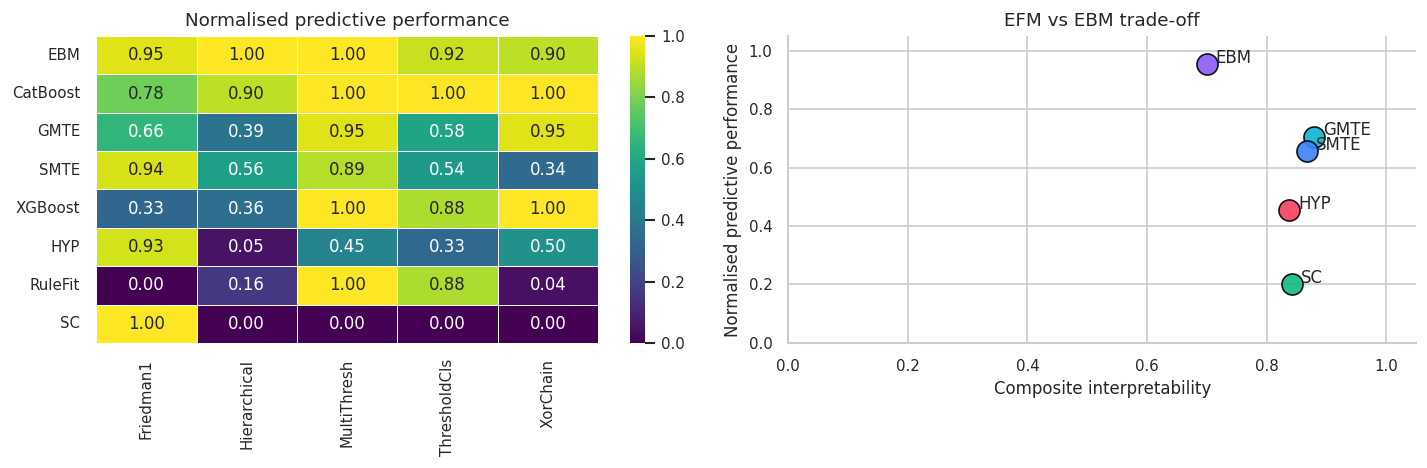

In [14]:
# Performance heatmap + EFM-vs-EBM trade-off

if not df_score.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left — performance heatmap
    heat = df_score.pivot_table(
        index="Model", columns="Dataset",
        values="PerfScore", aggfunc="mean",
    )
    if not model_summary.empty:
        heat = heat.reindex([m for m in model_summary["Model"] if m in heat.index])

    sns.heatmap(
        heat, cmap="viridis", vmin=0, vmax=1,
        annot=True, fmt=".2f", linewidths=0.5, ax=axes[0],
    )
    axes[0].set_title("Normalised predictive performance")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")

    # Right — EFM vs EBM scatter
    focus = ["SMTE", "GMTE", "HYP", "SC", "EBM"]
    trade = (
        df_score[df_score["Model"].isin(focus)]
        .groupby("Model", as_index=False)
        .agg(PerfScore=("PerfScore", "mean"), Composite_I=("Composite_I", "mean"))
    )
    for _, row in trade.iterrows():
        m = row["Model"]
        axes[1].scatter(
            row["Composite_I"], row["PerfScore"],
            s=160, color=MODEL_COLORS.get(m, "gray"),
            edgecolor="black", alpha=0.9,
        )
        axes[1].text(
            row["Composite_I"] + 0.015,
            row["PerfScore"] + 0.005, m, fontsize=10,
        )
    axes[1].set_title("EFM vs EBM trade-off")
    axes[1].set_xlabel("Composite interpretability")
    axes[1].set_ylabel("Normalised predictive performance")
    axes[1].set_xlim(0, 1.05)
    axes[1].set_ylim(0, 1.05)

    showfig()

In [15]:
# EFM vs EBM compact trade-off table

efm_ebm_summary = (
    df_score[df_score["Model"].isin(["SMTE", "GMTE", "HYP", "SC", "EBM"])]
    .groupby("Model", as_index=False)
    .agg(
        PerfScore_mean=("PerfScore", "mean"),
        PerfScore_std=("PerfScore", "std"),
        Composite_I_mean=("Composite_I", "mean"),
        Composite_I_std=("Composite_I", "std"),
        FeatSel_F1_mean=("FeatSel_F1", "mean"),
        RuleSparsity_mean=("RuleSparsity", "mean"),
        TrainTime_mean=("TrainTime", "mean"),
    )
    .sort_values(["Composite_I_mean", "PerfScore_mean"], ascending=False)
)

print("EFM vs EBM compact trade-off")
display(efm_ebm_summary.round(3))

EFM vs EBM compact trade-off


,Model,PerfScore_mean,PerfScore_std,Composite_I_mean,Composite_I_std,FeatSel_F1_mean,RuleSparsity_mean,TrainTime_mean
1,GMTE,0.7050,0.2440,0.8790,0.0530,1.0000,0.8590,2.8920
4,SMTE,0.6550,0.2520,0.8670,0.0720,1.0000,0.8480,4.9790
3,SC,0.2000,0.4470,0.8420,0.0530,1.0000,0.7710,3.4950
2,HYP,0.4530,0.3200,0.8380,0.0590,1.0000,0.7950,2.6560
0,EBM,0.9540,0.0470,0.7000,0.0000,1.0000,0.5000,98.5130


In [16]:
# Rule / Explanation comparison table

def _shorten(text: str, limit: int = 220) -> str:
    text = " ".join(str(text).replace("\n", " ").split())
    return text if len(text) <= limit else text[: limit - 1] + "…"


def metric_text(row: pd.Series) -> str:
    if row["Task"] == "regression":
        return f"RMSE={row['RMSE']:.3f}, R²={row['R2']:.3f}"
    return f"Acc={row['Accuracy']:.3f}, F1={row['F1']:.3f}"


def top_features_text(fi: np.ndarray, pp: PreparedData, k: int = 6) -> str:
    fi = np.asarray(fi, dtype=float)
    if fi.size == 0 or np.nanmax(fi) <= 0:
        return ""
    idx = np.argsort(fi)[::-1][:k]
    return ", ".join(f"{pp.feature_names[j]}:{fi[j]:.2f}" for j in idx if fi[j] > 1e-9)


def ebm_terms_text(model, pp: PreparedData, top_k: int = 5) -> str:
    try:
        imps = np.asarray(model.term_importances(), dtype=float)
        term_feats = getattr(model, "term_features_", None)
        term_names = getattr(model, "term_names_", None)
        pieces = []
        for t in np.argsort(np.abs(imps))[::-1][:top_k]:
            if term_feats is not None:
                name = " × ".join(pp.feature_names[j] for j in list(term_feats[t]))
            elif term_names is not None:
                name = str(term_names[t])
            else:
                name = f"term_{t}"
            pieces.append(f"{name} ({imps[t]:.2f})")
        return " | ".join(pieces)
    except Exception as e:
        return f"EBM terms unavailable: {type(e).__name__}"


def rulefit_rules_text(model, pp: PreparedData, top_k: int = 5) -> str:
    try:
        estimators = (
            model.estimators_
            if isinstance(model, OneVsRestClassifier) else [model]
        )
        pieces = []
        for ci, est in enumerate(estimators):
            if hasattr(est, "get_rules"):
                rtab = est.get_rules()
            elif hasattr(est, "_get_rules"):
                rtab = est._get_rules()
            else:
                continue

            if rtab is None or rtab.empty:
                continue
            rtab = rtab.copy()
            if "coef" in rtab.columns:
                rtab["_s"] = pd.to_numeric(rtab["coef"], errors="coerce").abs().fillna(0)
            elif "importance" in rtab.columns:
                rtab["_s"] = pd.to_numeric(rtab["importance"], errors="coerce").abs().fillna(0)
            else:
                rtab["_s"] = 0.0
            rtab = rtab.sort_values("_s", ascending=False)
            for _, row in rtab.head(top_k).iterrows():
                rule = str(row.get("rule", ""))
                if not rule or rule.lower() == "nan":
                    continue
                prefix = f"c{ci}: " if isinstance(model, OneVsRestClassifier) else ""
                pieces.append(prefix + _shorten(rule, 120))
                if len(pieces) >= top_k:
                    break
            if len(pieces) >= top_k:
                break
        return " | ".join(pieces) if pieces else "No compact RuleFit rules"
    except Exception as e:
        return f"RuleFit rules unavailable: {type(e).__name__}"


def explanation_text(seed: int, ds_name: str, model_name: str, top_k: int = 4) -> str:
    pp = prepared_data[(seed, ds_name)]
    model = trained_models.get((seed, ds_name, model_name))
    interp = interpretations.get((seed, ds_name, model_name), {})

    if model_name in PROPOSED_MODELS:
        rules = interp.get("rules", [])
        if not rules:
            return "No EFM rules extracted"
        return " | ".join(_shorten(r["rule_text"], 160) for r in rules[:top_k])

    if model_name == "EBM" and model is not None:
        return ebm_terms_text(model, pp, top_k=top_k)

    if model_name == "RuleFit" and model is not None:
        return rulefit_rules_text(model, pp, top_k=top_k)

    fi = interp.get("feature_importance", np.zeros(pp.X_train.shape[1]))
    return "Top features: " + top_features_text(fi, pp, k=top_k)


def build_explanation_table(seed: int = SEED, top_k: int = 4) -> pd.DataFrame:
    rows = []
    for ds_name, meta in SYNTHETIC_DATASETS.items():
        pp = prepared_data[(seed, ds_name)]
        for model_name in ALL_MODELS:
            key = (seed, ds_name, model_name)
            if key not in interpretations:
                continue
            sub = df_score[
                (df_score["Seed"] == seed)
                & (df_score["Dataset"] == ds_name)
                & (df_score["Model"] == model_name)
            ]
            if sub.empty:
                continue
            r = sub.iloc[0]
            interp = interpretations[key]
            fi = interp.get("feature_importance", np.zeros(pp.X_train.shape[1]))
            rows.append({
                "Dataset": ds_name,
                "Task": pp.task,
                "GroundTruth": meta["true_rule"],
                "Model": model_name,
                "Metric": metric_text(r),
                "PerfScore": r["PerfScore"],
                "Composite_I": r["Composite_I"],
                "TopFeatures": top_features_text(fi, pp, k=TOP_FEATURES_REPORT),
                "Explanation": explanation_text(seed, ds_name, model_name, top_k=top_k),
            })
    out = pd.DataFrame(rows)
    out["Model"] = pd.Categorical(out["Model"], categories=ALL_MODELS, ordered=True)
    return out.sort_values(["Dataset", "Model"]).reset_index(drop=True)


explain_table = build_explanation_table(seed=SEED, top_k=4)

print("Ground-truth rule  vs  learned explanations")
display(
    explain_table[[
        "Dataset", "Model", "Metric",
        "PerfScore", "Composite_I",
        "GroundTruth", "TopFeatures", "Explanation",
    ]].round(3)
)

Ground-truth rule  vs  learned explanations


,Dataset,Model,Metric,PerfScore,Composite_I,GroundTruth,TopFeatures,Explanation
0,Friedman1,SMTE,"RMSE=0.432, R²=0.992",0.9400,0.9200,10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4,"x2:1.00, x3:0.99, x1:0.97, x0:0.96, x4:0.50, x12:0.02, x10:0.01, x14:0.01","x0 < +0.344 (ev=-, m=0.06) AND x1 < +0.445 (ev=-, m=0.05) AND x14 < +0.289 (ev=+, m=0.05) AND x11 < +0.306 (ev=-, m=0.05) | x1 < +0.557 (ev=+, m=0.06) AND x3 > +0.637 (ev=-, m=..."
1,Friedman1,GMTE,"RMSE=0.638, R²=0.982",0.6550,0.9470,10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4,"x2:1.00, x3:0.98, x1:0.89, x0:0.85, x4:0.50, x6:0.02, x5:0.02, x10:0.02","x1 > +0.440 (ev=-, m=0.09) AND x0 > +0.687 (ev=+, m=0.06) | x0 > +0.460 (ev=-, m=0.08) AND x1 < +0.616 (ev=-, m=0.06) | x1 < +0.636 (ev=+, m=0.07) AND x0 > +0.663 (ev=+, m=0.06..."
2,Friedman1,HYP,"RMSE=0.438, R²=0.992",0.9320,0.9100,10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4,"x1:1.00, x3:1.00, x2:0.99, x0:0.98, x4:0.50, x5:0.03, x13:0.02, x14:0.02","x1 < +0.786 (ev=-, m=0.05) AND x0 > +0.745 (ev=+, m=0.05) | x1 < +0.585 (ev=+, m=0.05) | x0 > +0.346 (ev=-, m=0.05) AND x8 < +0.405 (ev=-, m=0.05) | x2 > +0.097 (ev=+, m=0.05) ..."
3,Friedman1,SC,"RMSE=0.389, R²=0.993",1.0000,0.9170,10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4,"x1:1.00, x0:0.96, x2:0.94, x3:0.93, x4:0.46, x10:0.01, x12:0.01, x14:0.01","x3 > +0.157 (ev=+, m=0.06) AND x14 < +0.220 (ev=-, m=0.06) AND x4 < +0.222 (ev=-, m=0.05) AND x9 > +0.231 (ev=-, m=0.05) | x3 < +0.897 (ev=-, m=0.06) AND x4 > +0.888 (ev=-, m=0..."
4,Friedman1,EBM,"RMSE=0.423, R²=0.992",0.9530,0.7000,10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4,"x3:1.00, x0:0.97, x1:0.93, x2:0.52, x4:0.51, x12:0.04, x10:0.04, x5:0.04",x3 (0.51) | x0 (0.38) | x1 (0.36) | x2 (0.26)
5,Friedman1,XGBoost,"RMSE=0.872, R²=0.966",0.3290,0.5750,10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4,"x3:1.00, x1:0.48, x0:0.46, x4:0.34, x2:0.24, x5:0.04, x13:0.02, x7:0.02","Top features: x3:1.00, x1:0.48, x0:0.46, x4:0.34"
6,Friedman1,CatBoost,"RMSE=0.548, R²=0.987",0.7790,0.5750,10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4,"x3:1.00, x1:0.90, x0:0.90, x2:0.43, x4:0.34, x10:0.00, x7:0.00, x5:0.00","Top features: x3:1.00, x1:0.90, x0:0.90, x2:0.43"
7,Friedman1,RuleFit,"RMSE=1.109, R²=0.946",0.0000,0.7000,10*sin(pi*x0*x1) + 20*(x2-0.5)^2 + 10*x3 + 5*x4,"x3:1.00, x1:0.98, x0:0.85, x4:0.41, x2:0.37, x8:0.01, x9:0.01, x10:0.00",x3 | x0 <= 0.17184 and x1 > 0.69006 | x0 > 1.66106 and x1 > -0.19138 and x4 <= 0.85938 | x4
8,Hierarchical,SMTE,"RMSE=0.570, R²=0.940",0.5610,0.9400,IF x0>0.5 AND x1<0 THEN +3; IF x2>1 THEN +2*x5; plus 1.5*x8 and 0.8*x0*x1,"x8:1.00, x1:0.53, x2:0.51, x0:0.50, x5:0.30, x9:0.04, x14:0.03, x7:0.03","x2 < +1.180 (ev=+, m=0.06) AND x5 < +0.712 (ev=+, m=0.05) | x2 < +0.562 (ev=-, m=0.06) AND x5 < +0.249 (ev=-, m=0.05) AND x12 > -0.325 (ev=+, m=0.05) AND x1 < -0.466 (ev=+, m=0..."
9,Hierarchical,GMTE,"RMSE=0.623, R²=0.928",0.3850,0.9130,IF x0>0.5 AND x1<0 THEN +3; IF x2>1 THEN +2*x5; plus 1.5*x8 and 0.8*x0*x1,"x8:1.00, x2:0.44, x0:0.43, x1:0.43, x5:0.30, x9:0.03, x11:0.03, x10:0.02","x5 < +1.334 (ev=+, m=0.05) AND x8 < +0.662 (ev=-, m=0.05) AND x2 < +1.035 (ev=+, m=0.05) | x8 > +0.679 (ev=+, m=0.07) AND x2 < +0.659 (ev=+, m=0.07) AND x0 > +0.666 (ev=-, m=0...."


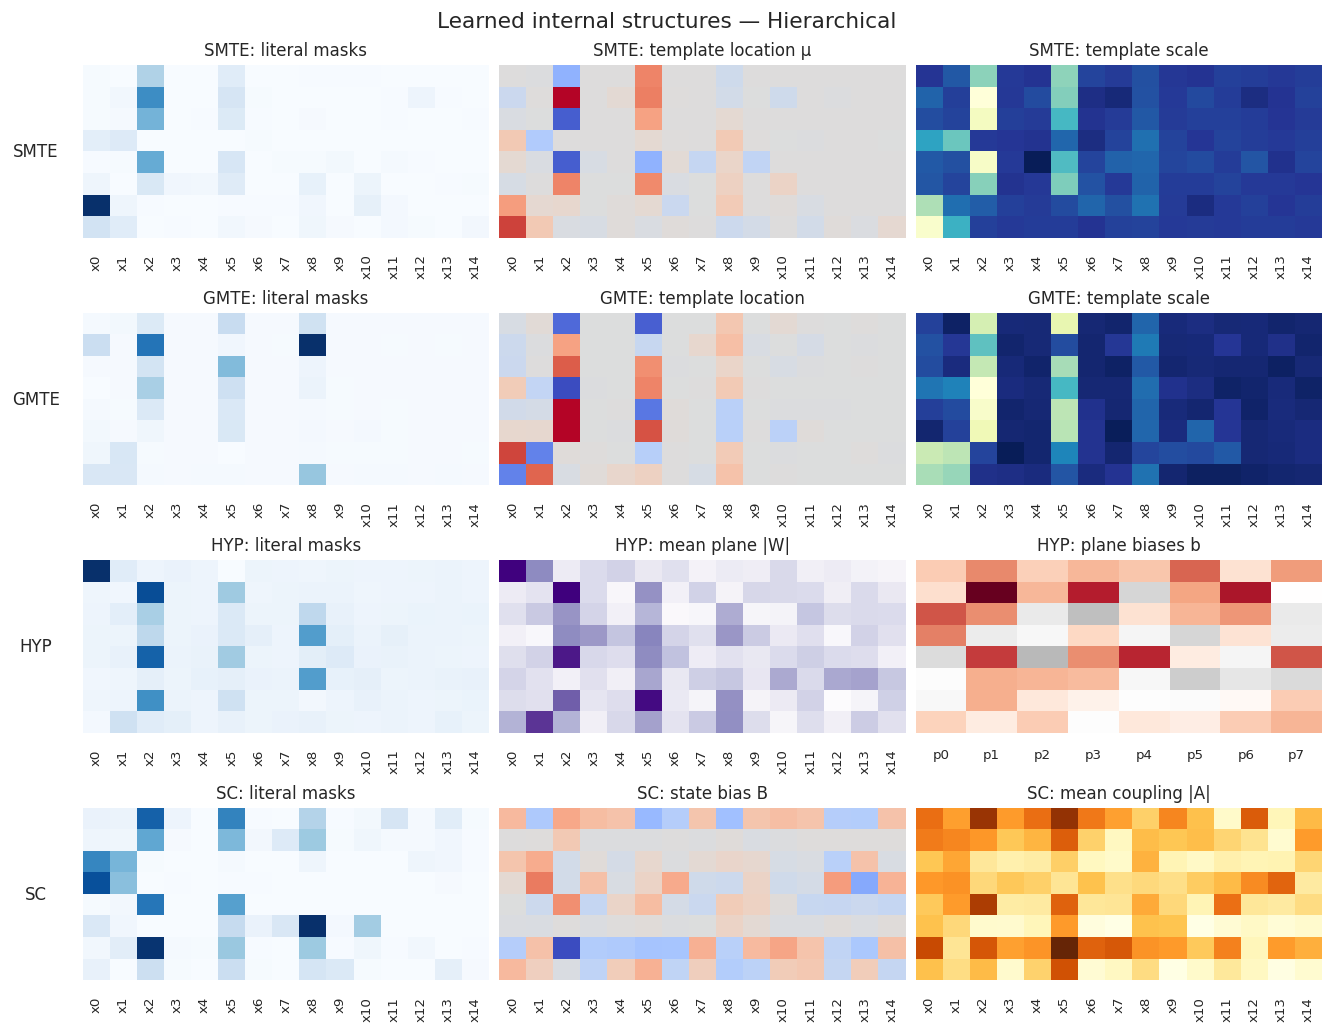

In [17]:
# Structure visualization

def plot_proposed_structure(seed: int = SEED, ds_name: str = "Hierarchical"):
    if (seed, ds_name) not in prepared_data:
        return
    pp = prepared_data[(seed, ds_name)]
    models_to_plot = ["SMTE", "GMTE", "HYP", "SC"]

    fig, axes = plt.subplots(
        len(models_to_plot), 3,
        figsize=(11, 8.5),
        constrained_layout=True,
    )

    def heat(ax, data, title, cmap="viridis", center=None,
             xticklabels=False):
        sns.heatmap(
            data, cmap=cmap, center=center,
            cbar=False,
            ax=ax,
            xticklabels=xticklabels,
            yticklabels=False,
            linewidths=0.0,
        )
        ax.set_title(title, fontsize=10)
        ax.tick_params(axis="both", labelsize=8)

    for row_idx, m_name in enumerate(models_to_plot):
        key = (seed, ds_name, m_name)
        if key not in trained_models:
            for c in range(3):
                axes[row_idx, c].axis("off")
            continue

        model = trained_models[key]
        idx, _ = top_rule_indices(model, 8)

        # Col 0 — literal masks
        mask = rule_mask_matrix(model)[idx]
        heat(axes[row_idx, 0], mask,
             f"{m_name}: literal masks",
             cmap="Blues", xticklabels=pp.feature_names)
        axes[row_idx, 0].set_ylabel(m_name, rotation=0, labelpad=28, va="center")

        # Col 1 — location / bias / plane sensitivity
        if m_name == "SMTE":
            loc = model.aggregator.mu.detach().cpu().numpy()[idx]
            lt, lc, lcen = "template location μ", "coolwarm", 0
        elif m_name == "GMTE":
            loc = model.aggregator.loc.detach().cpu().numpy()[idx]
            lt, lc, lcen = "template location", "coolwarm", 0
        elif m_name == "HYP":
            W = model.aggregator.W_plane.detach().cpu().numpy()[idx]
            loc = np.abs(W).mean(axis=1)
            lt, lc, lcen = "mean plane |W|", "Purples", None
        elif m_name == "SC":
            loc = model.aggregator.B.detach().cpu().numpy()[idx]
            lt, lc, lcen = "state bias B", "coolwarm", 0

        heat(axes[row_idx, 1], loc,
             f"{m_name}: {lt}",
             cmap=lc, center=lcen, xticklabels=pp.feature_names)

        # Col 2 — scale / coupling / plane biases
        if m_name == "SMTE":
            sc = F.softplus(model.aggregator.log_s).detach().cpu().numpy()[idx]
            st, scm, scen = "template scale", "YlGnBu", None
            xl = pp.feature_names
        elif m_name == "GMTE":
            sc = F.softplus(model.aggregator.log_scale).detach().cpu().numpy()[idx]
            st, scm, scen = "template scale", "YlGnBu", None
            xl = pp.feature_names
        elif m_name == "HYP":
            sc = model.aggregator.b_plane.detach().cpu().numpy()[idx]
            st, scm, scen = "plane biases b", "RdGy", 0
            xl = [f"p{p}" for p in range(sc.shape[1])]
        elif m_name == "SC":
            A = model.aggregator.A.detach().cpu().numpy()[idx]
            sc = np.abs(A).mean(axis=1)
            st, scm, scen = "mean coupling |A|", "YlOrBr", None
            xl = pp.feature_names

        heat(axes[row_idx, 2], sc,
             f"{m_name}: {st}",
             cmap=scm, center=scen, xticklabels=xl)

    fig.suptitle(f"Learned internal structures — {ds_name}", fontsize=13)
    plt.show()


plot_proposed_structure(ds_name="Hierarchical")

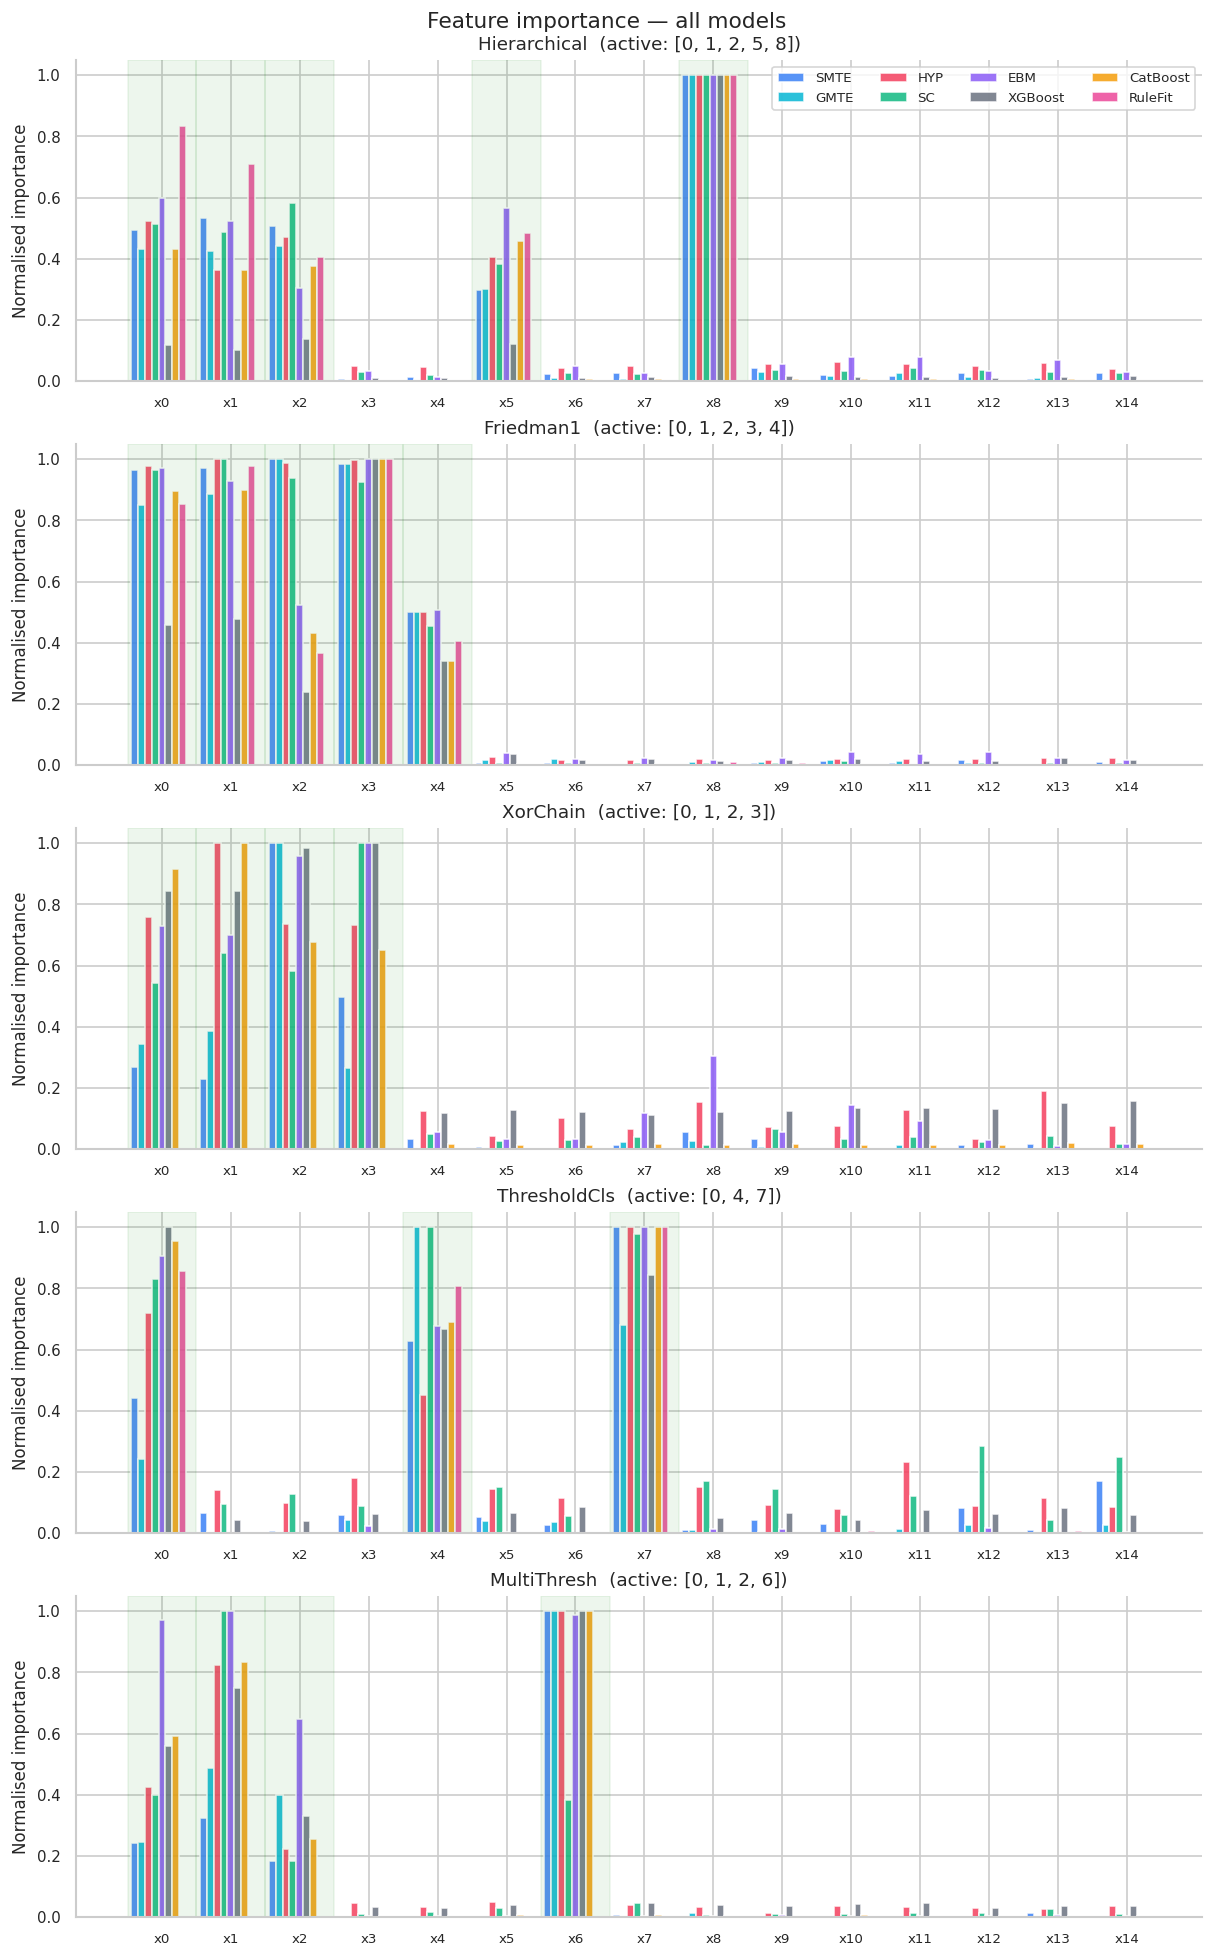

In [18]:
# All-models feature-importance comparison per dataset

def plot_feature_importance_comparison(seed: int = SEED):
    ds_names = list(SYNTHETIC_DATASETS.keys())
    n_ds = len(ds_names)
    fig, axes = plt.subplots(n_ds, 1, figsize=(10, 3.2 * n_ds),
                              constrained_layout=True)
    if n_ds == 1:
        axes = [axes]

    for ax, ds_name in zip(axes, ds_names):
        pp = prepared_data[(seed, ds_name)]
        meta = SYNTHETIC_DATASETS[ds_name]
        active = set(meta["active_feats"].keys())
        D = len(pp.feature_names)
        x_pos = np.arange(D)
        bar_w = 0.8 / len(ALL_MODELS)

        for mi, m_name in enumerate(ALL_MODELS):
            interp = interpretations.get((seed, ds_name, m_name))
            if interp is None:
                continue
            fi = np.asarray(
                interp.get("feature_importance", np.zeros(D)), dtype=float,
            )
            fi = fi / (fi.max() + 1e-12)
            ax.bar(
                x_pos + mi * bar_w,
                fi,
                width=bar_w,
                color=MODEL_COLORS.get(m_name, "gray"),
                label=m_name if ax is axes[0] else None,
                alpha=0.85,
            )

        # highlight ground-truth features
        for j in active:
            ax.axvspan(j - 0.1, j + len(ALL_MODELS) * bar_w + 0.1,
                       color="green", alpha=0.07)

        ax.set_xticks(x_pos + 0.4)
        ax.set_xticklabels(pp.feature_names, fontsize=8)
        ax.set_ylabel("Normalised importance")
        ax.set_title(f"{ds_name}  (active: {sorted(active)})")

    axes[0].legend(fontsize=8, ncol=4, loc="upper right")
    fig.suptitle("Feature importance — all models", fontsize=13, y=1.01)
    plt.show()


plot_feature_importance_comparison()

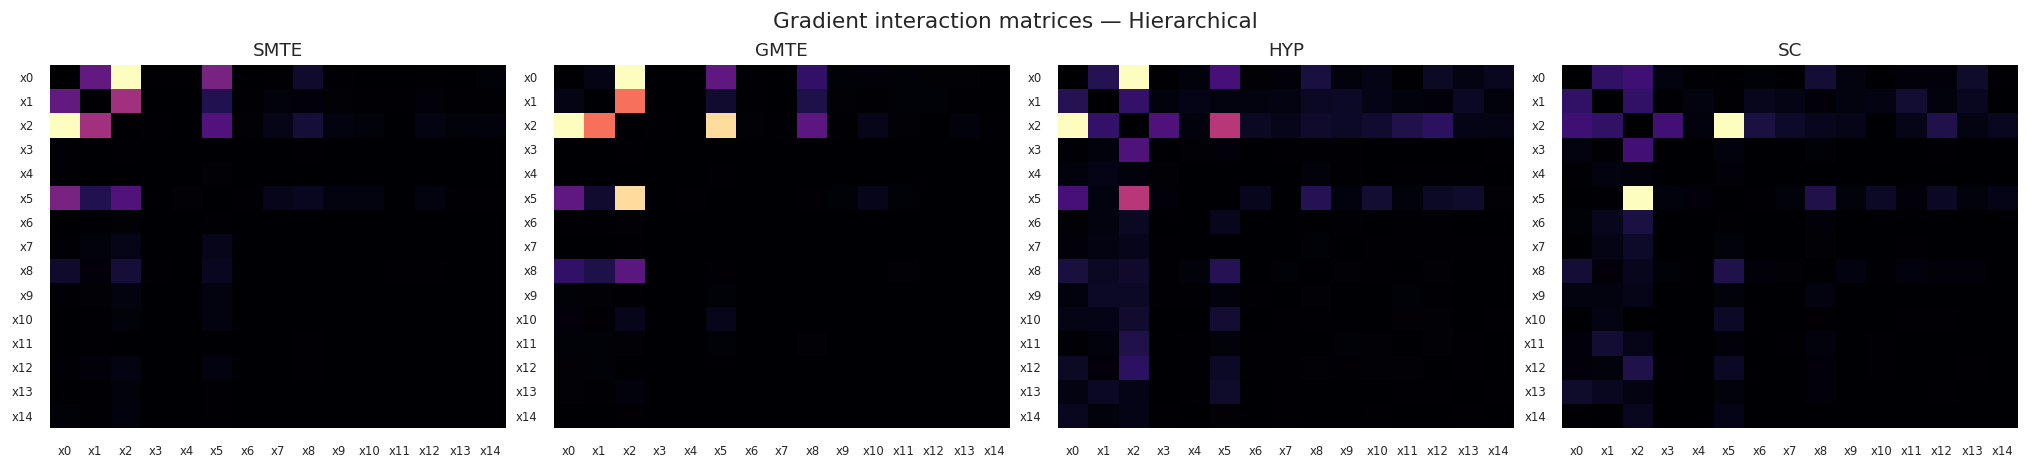

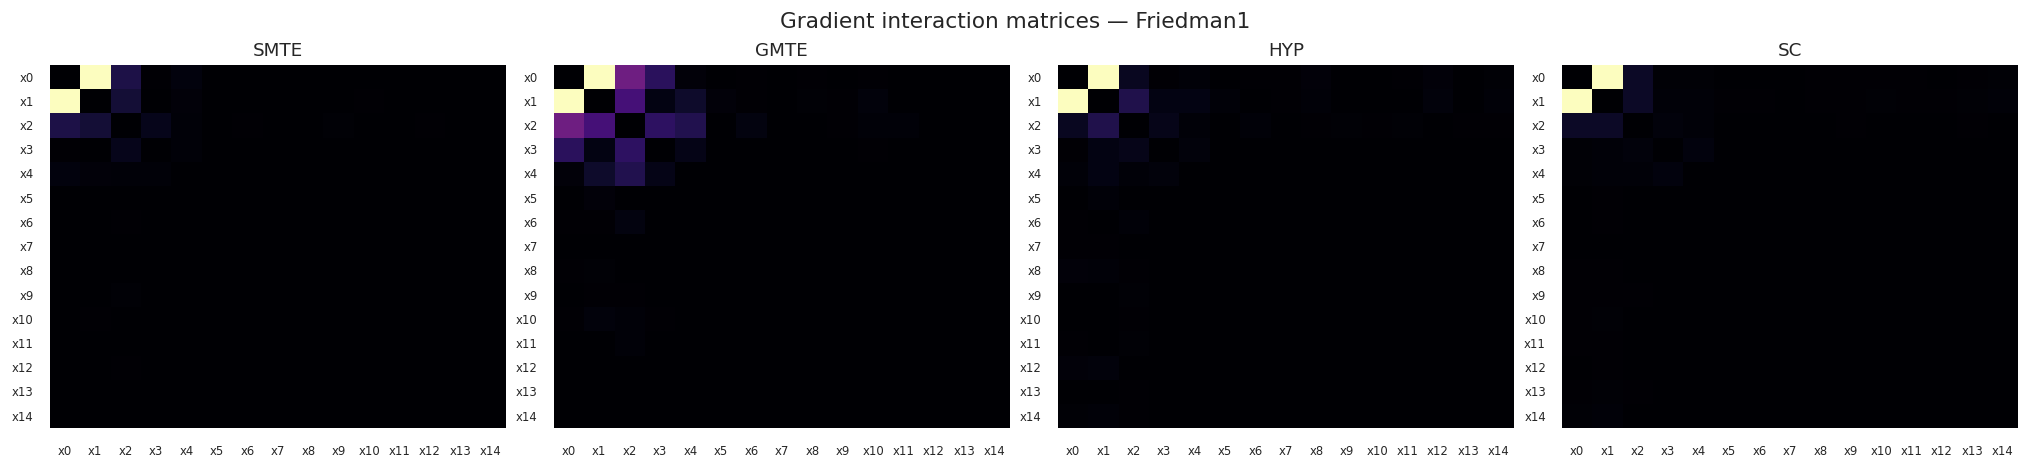

In [19]:
# Interaction matrices for EFM variants

def plot_interaction_matrices(seed: int = SEED, ds_name: str = "Hierarchical"):
    if (seed, ds_name) not in prepared_data:
        return
    pp = prepared_data[(seed, ds_name)]
    efm_models = [m for m in ["SMTE", "GMTE", "HYP", "SC"]
                  if (seed, ds_name, m) in interpretations]
    if not efm_models:
        return

    n = len(efm_models)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.8), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, m_name in zip(axes, efm_models):
        M = interpretations[(seed, ds_name, m_name)]["interaction_matrix"]
        sns.heatmap(
            M, cmap="magma", vmin=0, vmax=1,
            xticklabels=pp.feature_names,
            yticklabels=pp.feature_names,
            cbar=False, ax=ax, linewidths=0,
        )
        ax.set_title(m_name, fontsize=11)
        ax.tick_params(labelsize=7)

    fig.suptitle(f"Gradient interaction matrices — {ds_name}", fontsize=13)
    plt.show()


plot_interaction_matrices(ds_name="Hierarchical")
plot_interaction_matrices(ds_name="Friedman1")

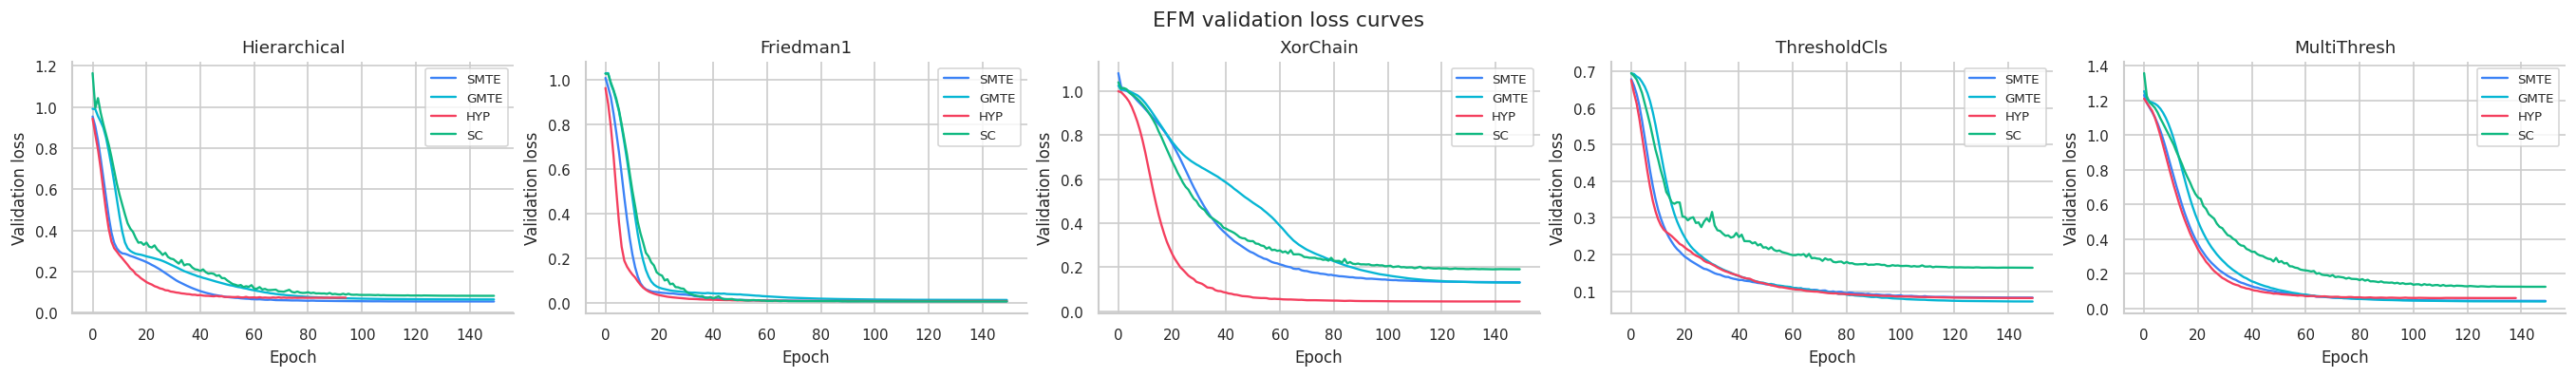

In [20]:
# Training loss curves for EFM variants

def plot_training_curves(seed: int = SEED):
    ds_names = [d for d in SYNTHETIC_DATASETS
                if any((seed, d, m) in histories for m in PROPOSED_MODELS)]
    if not ds_names:
        return

    n = len(ds_names)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 3.2), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, ds_name in zip(axes, ds_names):
        for m_name in ["SMTE", "GMTE", "HYP", "SC"]:
            h = histories.get((seed, ds_name, m_name))
            if h is None:
                continue
            ax.plot(
                h["epoch"], h["val_loss"],
                label=m_name, color=MODEL_COLORS[m_name], linewidth=1.4,
            )
        ax.set_title(ds_name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation loss")
        ax.legend(fontsize=8)

    fig.suptitle("EFM validation loss curves", fontsize=13)
    plt.show()


plot_training_curves()